# Clasificación de posts del blog — NU★B Studio

**Auto-etiquetado: predecir las etiquetas de un post a partir de su texto (aprendizaje supervisado)**

Este cuaderno entrena un modelo de **clasificación de texto multi-etiqueta**: dado el texto de
un post, predice sus etiquetas (`pintura`, `escultura`, `huasteca`, …). Aprende de los posts
ya etiquetados a mano (el *ground truth*).

### Modelos que se usan y por qué
| Parte | Técnica | Motivo |
|---|---|---|
| Texto → números | **TF-IDF** | Pondera cada palabra por lo característica que es del post |
| Clasificación | **Regresión Logística + One-vs-Rest** | Transparente y sólido para multi-etiqueta; se compara contra SVM y Naive Bayes |

> La otra parte de la tarjeta — **posts relacionados** — se resuelve en un cuaderno aparte
> (`sistema_recomendacion_posts.ipynb`) con **K-Means** (no supervisado).


## 1. Librerías

In [1]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             hamming_loss, classification_report)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Librerías cargadas.")

Librerías cargadas.


## 2. Cargar los datos

Se intenta leer **en vivo desde Neon** (la BD del backend). Si no hay conexión
—p. ej. al calificar en otra máquina— se usa el **CSV de respaldo** `blog_posts_dataset.csv`
que acompaña al cuaderno. En ambos casos el resultado es idéntico.

In [2]:
BASE_DIR = os.path.dirname(os.path.abspath("__file__")) if "__file__" in globals() else os.getcwd()
CSV_PATH = os.path.join(BASE_DIR, "blog_posts_dataset.csv")
ENV_PATH = os.path.abspath(os.path.join(BASE_DIR, "..", ".env"))

QUERY = '''
  SELECT p.id_post, p.titulo, COALESCE(p.extracto,'') AS extracto,
         COALESCE(p.contenido,'') AS contenido,
         string_agg(be.slug, '|' ORDER BY be.slug) AS etiquetas
  FROM blog_posts p
  JOIN blog_posts_etiquetas bpe ON bpe.id_post = p.id_post
  JOIN blog_etiquetas be ON be.id_blog_etiqueta = bpe.id_blog_etiqueta
  WHERE COALESCE(p.eliminado, false) = false
  GROUP BY p.id_post
'''

df = None
try:
    import psycopg2
    from dotenv import load_dotenv
    load_dotenv(ENV_PATH)
    conn = psycopg2.connect(
        host=os.environ["DB_HOST"], user=os.environ["DB_USER"],
        password=os.environ["DB_PASSWORD"], dbname=os.environ["DB_NAME"],
        port=os.environ.get("DB_PORT", "5432"), sslmode="require")
    df = pd.read_sql(QUERY, conn)
    conn.close()
    print(f"✓ Cargado EN VIVO desde Neon: {len(df)} posts")
except Exception as e:
    print(f"Sin conexión a Neon ({type(e).__name__}). Uso el CSV de respaldo.")
    df = pd.read_csv(CSV_PATH)
    print(f"✓ Cargado desde CSV: {len(df)} posts")

df["etiquetas"] = df["etiquetas"].apply(lambda s: s.split("|") if isinstance(s, str) else [])
df.head(3)

✓ Cargado EN VIVO desde Neon: 241 posts


,id_post,titulo,extracto,contenido,etiquetas
0,263,El paisaje serrano: técnica y memoria,El paisaje serrano — apuntes sobre fotografia ...,<p>Una buena imagen no se toma: se construye c...,"[fotografia, paisaje]"
1,264,El paisaje serrano paso a paso,El paisaje serrano — apuntes sobre fotografia ...,<p>Una buena imagen no se toma: se construye c...,[fotografia]
2,265,Cinco ideas sobre las figuras rituales,Las figuras rituales — apuntes sobre escultura...,"<p>Del bloque informe emerge, poco a poco, una...","[escultura, naturaleza]"


## 3. Exploración de los datos

Antes de modelar, entendemos el balance de clases y cuántas etiquetas tiene cada post.

Posts totales        : 241
Etiquetas distintas  : 12
Relaciones post↔tag  : 573
Etiquetas por post   : media 2.38  (min 1, max 4)


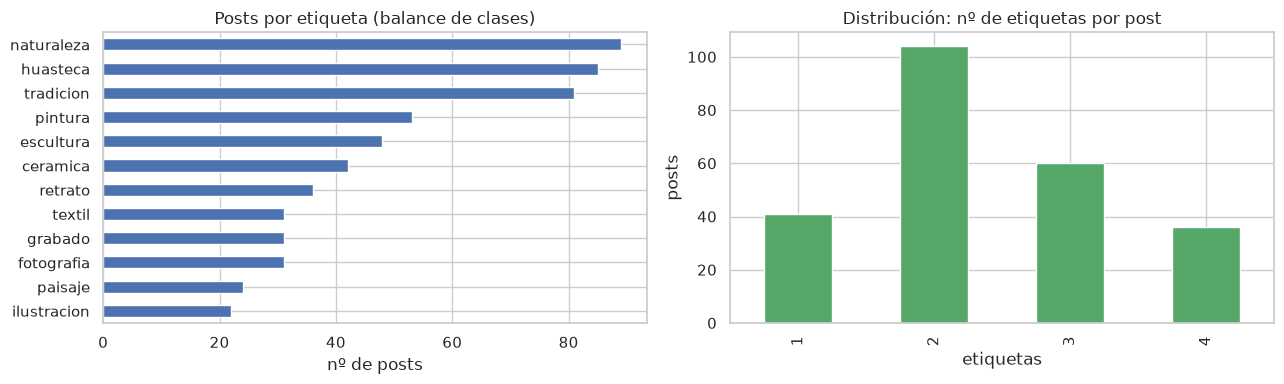

In [3]:
all_tags = [t for tags in df["etiquetas"] for t in tags]
tag_counts = pd.Series(all_tags).value_counts()
n_tags_per_post = df["etiquetas"].apply(len)

print(f"Posts totales        : {len(df)}")
print(f"Etiquetas distintas  : {tag_counts.size}")
print(f"Relaciones post↔tag  : {len(all_tags)}")
print(f"Etiquetas por post   : media {n_tags_per_post.mean():.2f}  (min {n_tags_per_post.min()}, max {n_tags_per_post.max()})")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
tag_counts.sort_values().plot.barh(ax=ax[0], color="#4C72B0")
ax[0].set_title("Posts por etiqueta (balance de clases)"); ax[0].set_xlabel("nº de posts")
n_tags_per_post.value_counts().sort_index().plot.bar(ax=ax[1], color="#55A868")
ax[1].set_title("Distribución: nº de etiquetas por post"); ax[1].set_xlabel("etiquetas"); ax[1].set_ylabel("posts")
plt.tight_layout(); plt.show()

## 4. Limpieza del texto

El campo `contenido` trae HTML (`<p>`, `<strong>`, …). Lo quitamos y concatenamos
**título + extracto + contenido** en un solo campo de texto por post. Ese es el texto
que el modelo "lee".

In [4]:
def limpiar_html(texto: str) -> str:
    texto = re.sub(r"<[^>]+>", " ", str(texto))     # quita etiquetas HTML
    texto = re.sub(r"&[a-z]+;", " ", texto)          # entidades &nbsp; etc.
    texto = re.sub(r"\s+", " ", texto)              # colapsa espacios
    return texto.strip().lower()

df["texto"] = (df["titulo"].fillna("") + ". " +
               df["extracto"].fillna("") + ". " +
               df["contenido"].fillna("")).apply(limpiar_html)

print("Ejemplo de texto ya limpio:\n")
print(df["texto"].iloc[0][:300], "...")

Ejemplo de texto ya limpio:

el paisaje serrano: técnica y memoria. el paisaje serrano — apuntes sobre fotografia de la huasteca hidalguense.. una buena imagen no se toma: se construye con paciencia y mirada. el encuadre decide qué entra y qué se queda fuera; ahí está la mitad del mensaje. la luz de la mañana modela los rostros ...


## 5. TF-IDF — convertir texto en números

**TF-IDF** da a cada palabra un peso = *qué tan característica es de ESE post*:
sube el peso de palabras raras y específicas (`gubia`, `telar`, `barro`) y baja el de
las comunes (`de`, `arte`, `obra`). Usamos también bigramas (pares de palabras) y una
lista de *stopwords* en español.

In [5]:
STOPWORDS_ES = """a al algo algunas algunos ante antes como con contra cual cuando de del desde donde
dos el ella ellas ellos en entre era erais eran eras es esa esas ese eso esos esta estas este esto estos
fue fueron ha hasta hay la las le les lo los mas me mi mis mucho muy nada ni no nos nosotros o os otra
otras otro otros para pero poco por porque que quien se sea sean si sin sobre su sus tan te tiene tienen
todo todos tu tus un una uno unas unos y ya""".split()

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),      # palabras sueltas y pares
    min_df=2,                # ignora palabras que salen en 1 solo post
    max_features=5000,
    stop_words=STOPWORDS_ES,
)
X = vectorizer.fit_transform(df["texto"])
print(f"Matriz TF-IDF: {X.shape[0]} posts × {X.shape[1]} términos (palabras/bigramas)")

Matriz TF-IDF: 241 posts × 1342 términos (palabras/bigramas)


## 6. Etiquetas a formato multi-etiqueta

`MultiLabelBinarizer` convierte la lista de etiquetas de cada post en un vector de 0/1
(una columna por etiqueta). Es la forma que el clasificador entiende.

In [6]:
mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(df["etiquetas"])
clases = list(mlb.classes_)
print("Etiquetas (clases):", clases)
print("Forma de Y:", Y.shape, "→ una columna por etiqueta")

Etiquetas (clases): ['ceramica', 'escultura', 'fotografia', 'grabado', 'huasteca', 'ilustracion', 'naturaleza', 'paisaje', 'pintura', 'retrato', 'textil', 'tradicion']
Forma de Y: (241, 12) → una columna por etiqueta


## 7. Comparación de modelos

Antes de decidir, comparamos tres clasificadores clásicos de texto con **validación cruzada
5-fold** (entrena con 4/5, evalúa en el 1/5 no visto). Todos envueltos en **One-vs-Rest**
(un clasificador por etiqueta):

- **Regresión Logística** — pesos aprendidos por palabra.
- **SVM lineal (LinearSVC)** — traza la mejor frontera entre clases.
- **Naive Bayes** — probabilidad por conteo de palabras (la línea base histórica del texto).

,F1 micro,F1 macro
Modelo,,
Regresión Logística,0.648,0.736
SVM lineal,0.644,0.731
Naive Bayes,0.657,0.719


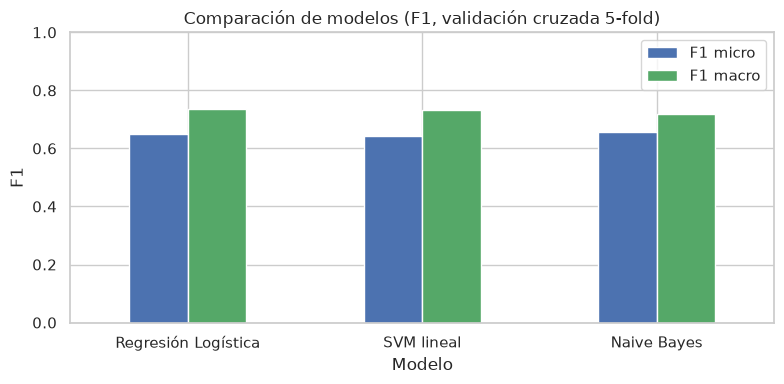

In [7]:
modelos = {
    "Regresión Logística": LogisticRegression(max_iter=1000, C=5, class_weight="balanced"),
    "SVM lineal":          LinearSVC(C=1.0, class_weight="balanced"),
    "Naive Bayes":         MultinomialNB(),
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
resultados = []
for nombre, base in modelos.items():
    fm, fM = [], []
    for tr, te in kf.split(X):
        clf = OneVsRestClassifier(base)
        clf.fit(X[tr], Y[tr])
        pred = clf.predict(X[te])
        fm.append(f1_score(Y[te], pred, average="micro", zero_division=0))
        fM.append(f1_score(Y[te], pred, average="macro", zero_division=0))
    resultados.append({"Modelo": nombre,
                       "F1 micro": np.mean(fm), "F1 macro": np.mean(fM)})

tabla = pd.DataFrame(resultados).set_index("Modelo").round(3)
display(tabla)
tabla.plot.bar(figsize=(8,4), rot=0, color=["#4C72B0","#55A868"])
plt.title("Comparación de modelos (F1, validación cruzada 5-fold)")
plt.ylim(0,1); plt.ylabel("F1"); plt.tight_layout(); plt.show()

## 8. Modelo elegido y evaluación final

Elegimos **Regresión Logística** (transparente y competitiva). Hacemos un split
train/test 80/20 y reportamos el desempeño por etiqueta.

In [8]:
X_tr, X_te, Y_tr, Y_te = train_test_split(X, Y, test_size=0.2, random_state=RANDOM_STATE)

modelo = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, C=5, class_weight="balanced"))
modelo.fit(X_tr, Y_tr)
pred = modelo.predict(X_te)

print("F1 micro :", round(f1_score(Y_te, pred, average="micro",  zero_division=0), 3))
print("F1 macro :", round(f1_score(Y_te, pred, average="macro",  zero_division=0), 3))
print("Precision:", round(precision_score(Y_te, pred, average="micro", zero_division=0), 3))
print("Recall   :", round(recall_score(Y_te, pred, average="micro", zero_division=0), 3))
print("Hamming loss (menor=mejor):", round(hamming_loss(Y_te, pred), 3))
print("\n--- Reporte por etiqueta ---")
print(classification_report(Y_te, pred, target_names=clases, zero_division=0))

F1 micro : 0.684
F1 macro : 0.775
Precision: 0.626
Recall   : 0.754
Hamming loss (menor=mejor): 0.145

--- Reporte por etiqueta ---
              precision    recall  f1-score   support

    ceramica       1.00      1.00      1.00         9
   escultura       0.67      1.00      0.80        12
  fotografia       1.00      1.00      1.00         7
     grabado       1.00      1.00      1.00         2
    huasteca       0.48      0.68      0.57        19
 ilustracion       1.00      1.00      1.00         4
  naturaleza       0.30      0.32      0.31        19
     paisaje       0.38      0.60      0.46         5
     pintura       1.00      1.00      1.00         7
     retrato       0.50      0.67      0.57         6
      textil       1.00      1.00      1.00        11
   tradicion       0.54      0.67      0.60        21

   micro avg       0.63      0.75      0.68       122
   macro avg       0.74      0.83      0.78       122
weighted avg       0.65      0.75      0.69       122
 s

### 8.1 Desempeño por etiqueta (visual)

F1 por cada una de las 12 etiquetas en el conjunto de prueba.

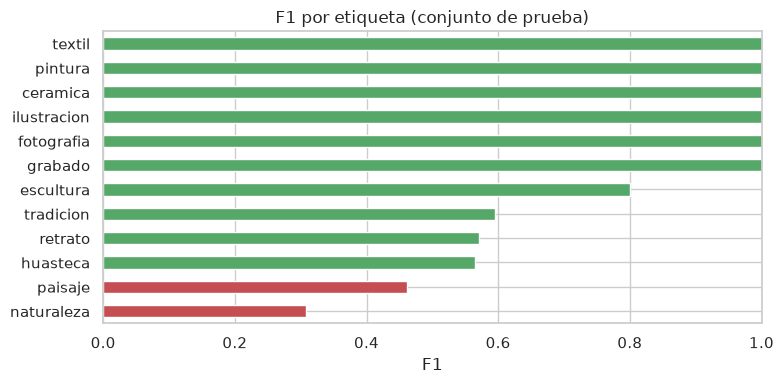

In [9]:
f1_por_clase = f1_score(Y_te, pred, average=None, zero_division=0)
serie = pd.Series(f1_por_clase, index=clases).sort_values()
plt.figure(figsize=(8,4))
serie.plot.barh(color=["#C44E52" if v < 0.5 else "#55A868" for v in serie])
plt.title("F1 por etiqueta (conjunto de prueba)"); plt.xlabel("F1"); plt.xlim(0,1)
plt.tight_layout(); plt.show()

## 9. El modelo clasificando en vivo (auto-etiquetado)

Esta es la feature que va a la app: se le pasa el **texto de un post nuevo** y el modelo
**sugiere sus etiquetas** con su probabilidad. Reentrenamos el vectorizador y el modelo
con **todos** los datos para el uso real.

In [10]:
vectorizer_full = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=5000, stop_words=STOPWORDS_ES)
X_full = vectorizer_full.fit_transform(df["texto"])
modelo_full = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, C=5, class_weight="balanced"))
modelo_full.fit(X_full, Y)

def sugerir_etiquetas(texto, umbral=0.30, top=4):
    v = vectorizer_full.transform([limpiar_html(texto)])
    probs = modelo_full.predict_proba(v)[0]
    ranking = sorted(zip(clases, probs), key=lambda x: x[1], reverse=True)
    elegidas = [(c, p) for c, p in ranking if p >= umbral][:top]
    return elegidas or ranking[:1]   # al menos una

ejemplo = """En el taller aprendimos a modelar el barro con las manos y el torno.
Cada pieza de cerámica se cuece en horno y luego se decora con esmaltes tradicionales
de la Huasteca."""
print("Texto de prueba:\n", ejemplo, "\n")
print("Etiquetas sugeridas por el modelo:")
for c, p in sugerir_etiquetas(ejemplo):
    print(f"  · {c:<14} {p:.0%}")

Texto de prueba:
 En el taller aprendimos a modelar el barro con las manos y el torno.
Cada pieza de cerámica se cuece en horno y luego se decora con esmaltes tradicionales
de la Huasteca. 

Etiquetas sugeridas por el modelo:
  · tradicion      51%
  · naturaleza     50%
  · ceramica       42%
  · huasteca       38%


## 10. Exportar el modelo entrenado

Guardamos el vectorizador TF-IDF + el clasificador entrenados en `modelo_clasificacion.joblib`.
Este archivo es el que carga el microservicio para servir el **auto-etiquetado** en vivo.

In [11]:
import joblib

joblib.dump({"vectorizer": vectorizer_full, "modelo": modelo_full, "clases": clases},
            os.path.join(BASE_DIR, "modelo_clasificacion.joblib"))
print("✓ modelo_clasificacion.joblib guardado")

✓ modelo_clasificacion.joblib guardado


## 11. Conclusiones

- **Clasificación (auto-etiquetado):** la Regresión Logística + One-vs-Rest sobre TF-IDF
  clasifica los posts en sus 12 etiquetas con un **F1 sólido** (ver §7–8), superando
  claramente al azar y compitiendo con SVM/Naive Bayes de forma transparente.
- Es un modelo **supervisado**: aprende de los posts ya etiquetados a mano.
- **Uso en la app:** el modelo sugiere etiquetas al artista cuando escribe un post
  (patrón "el sistema sugiere, el humano confirma").

> La **recomendación de posts relacionados** se resuelve en un cuaderno aparte
> (`sistema_recomendacion_posts.ipynb`) con **K-Means** (aprendizaje no supervisado).
